# Numerical Simulation of Orbital Motion

## Aim / Objective
To computationally investigate the motion of a body under an attractive inverse-square gravitational force, governed by the potential $V(r) = -\frac{4\pi^2}{r}$. 

Specifically, this notebook aims to:
1. **Simulate Trajectories:** Use Euler's method to numerically integrate the equations of motion and demonstrate various orbital shapes (circular and elliptical) by adjusting initial velocity parameters.
2. **Analyze Step-Size Dependence:** Investigate how the choice of time step-size ($\Delta t$) in Euler's method affects the stability and accuracy of a closed trajectory.
3. **Evaluate Energy Conservation:** Plot the total energy of the system at each time step to analyze the conservation properties (and inherent numerical drift) of the Euler integration scheme.

## Mathematical Analysis

### 1. Derivation of the Potential Energy
For a conservative force, the force $\vec{F}$ is the negative gradient of the potential energy $V$. In one radial dimension, this is expressed as:
$$F(r) = -\frac{dV}{dr}$$
This means the potential energy at a distance $r$ is the negative work done to bring a mass from infinity (where potential energy is defined as zero, $V(\infty) = 0$) to $r$:
$$V(r) - V(\infty) = -\int_{\infty}^{r} F(r') dr'$$

We are given an attractive inverse-square gravitational force:
$$F(r) = -\frac{k}{r^2}$$
where $k = 4\pi^2$. Substituting this into the integral:
$$V(r) - 0 = -\int_{\infty}^{r} \left( -\frac{k}{r'^2} \right) dr'$$
The negative signs cancel out:
$$V(r) = k \int_{\infty}^{r} r'^{-2} dr'$$
Applying the power rule for integration $\int x^n dx = \frac{x^{n+1}}{n+1}$:
$$V(r) = k \left[ \frac{r'^{-1}}{-1} \right]_{\infty}^{r} = -k \left[ \frac{1}{r'} \right]_{\infty}^{r}$$
Evaluating the limits:
$$V(r) = -k \left( \frac{1}{r} - \frac{1}{\infty} \right)$$
Since $\frac{1}{\infty}$ approaches 0, we arrive at the potential energy formula for our system:
$$V(r) = -\frac{k}{r} = -\frac{4\pi^2}{r}$$

### 2. Equations of Motion
The force acting on a unit mass is $\vec{F} = -\frac{k}{r^2} \hat{r}$. To solve this numerically, we decompose the motion into Cartesian coordinates $(x, y)$. The distance from the center of force is $r = \sqrt{x^2 + y^2}$. 

The components of the acceleration vector $\vec{a} = \frac{d^2\vec{r}}{dt^2}$ are derived from the force components $F_x = F \cos(\theta) = F \frac{x}{r}$ and $F_y = F \sin(\theta) = F \frac{y}{r}$:
$$\frac{d^2x}{dt^2} = -\frac{k x}{r^3} = -\frac{4\pi^2 x}{(x^2 + y^2)^{3/2}}$$
$$\frac{d^2y}{dt^2} = -\frac{k y}{r^3} = -\frac{4\pi^2 y}{(x^2 + y^2)^{3/2}}$$

### 3. Numerical Integration: Euler's Method
To apply Euler's method, we reduce the two second-order differential equations into a system of four first-order differential equations by introducing velocity components $v_x$ and $v_y$:
1. $\frac{dx}{dt} = v_x$
2. $\frac{dy}{dt} = v_y$
3. $\frac{dv_x}{dt} = a_x(x,y) = -\frac{4\pi^2 x}{(x^2 + y^2)^{3/2}}$
4. $\frac{dv_y}{dt} = a_y(x,y) = -\frac{4\pi^2 y}{(x^2 + y^2)^{3/2}}$

Given a small time step $\Delta t$, the state of the system is updated iteratively using the first derivative:
$$x_{i+1} = x_i + v_{x,i} \Delta t$$
$$y_{i+1} = y_i + v_{y,i} \Delta t$$
$$v_{x,i+1} = v_{x,i} + a_{x,i} \Delta t$$
$$v_{y,i+1} = v_{y,i} + a_{y,i} \Delta t$$

### 4. Energy Conservation Tracking
The total energy $E$ per unit mass of the system is the sum of its kinetic ($T$) and potential ($V$) energies:
$$E = T + V = \frac{1}{2}(v_x^2 + v_y^2) - \frac{4\pi^2}{\sqrt{x^2 + y^2}}$$
In a continuous, idealized physical system, $E$ is strictly conserved. However, Euler's method is a first-order numerical integrator. The local truncation error is proportional to $\Delta t^2$, which systematically adds artificial energy to the system over time (numerical drift). We will plot $E(t)$ to observe this instability and its dependence on step-size.

### 5. Initial Conditions for Orbital Shapes
To obtain different orbital trajectories, we will start the body at a fixed perihelion on the x-axis $(x_0 = 1, y_0 = 0)$ and adjust only the initial velocity in the y-direction $(v_{x,0} = 0, v_{y,0} = v_0)$.

* **Circular Orbit:** The required centripetal acceleration must exactly match the gravitational acceleration ($\frac{v^2}{r} = \frac{k}{r^2}$).
  $$v_{circ} = \sqrt{\frac{k}{r}}$$
  For $r_0 = 1$ and $k = 4\pi^2$, the required velocity is $v_{circ} = 2\pi \approx 6.283$.
* **Elliptical Orbit:** We choose an initial velocity less than the escape velocity ($v_{esc} = \sqrt{2}v_{circ}$) but different from $v_{circ}$. For example, $v_0 = 4.5$.

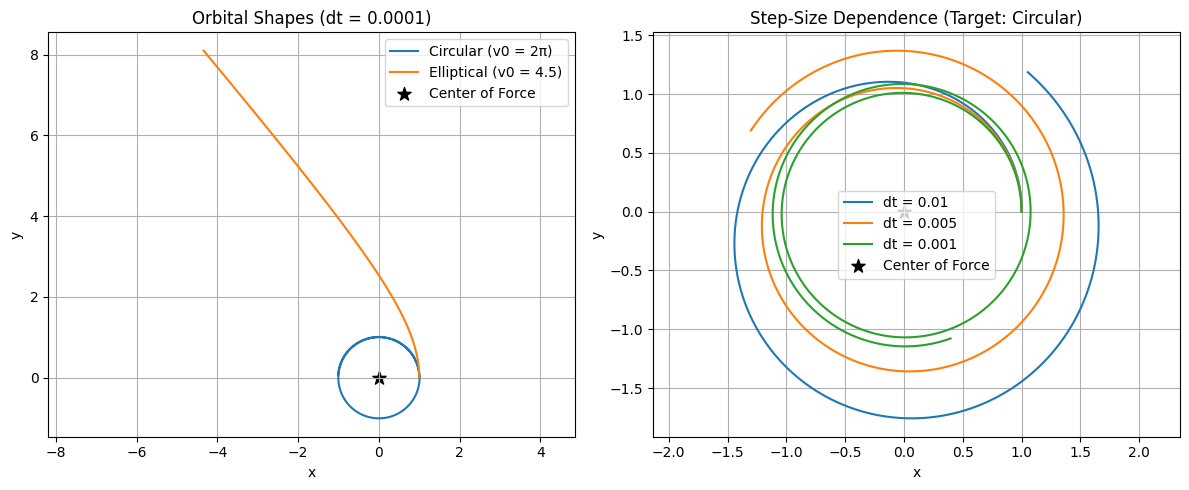

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define the constants
k = 4 * np.pi**2

def euler_orbit(r0, v0, dt, total_time):
    """
    Numerically integrates the equations of motion using Euler's method.
    """
    steps = int(total_time / dt)
    
    # Initialize arrays
    x = np.zeros(steps)
    y = np.zeros(steps)
    vx = np.zeros(steps)
    vy = np.zeros(steps)
    energy = np.zeros(steps)
    
    # Set initial conditions
    x[0], y[0] = r0
    vx[0], vy[0] = v0
    
    for i in range(steps - 1):
        r = np.sqrt(x[i]**2 + y[i]**2)
        
        # Calculate Energy at current step
        energy[i] = 0.5 * (vx[i]**2 + vy[i]**2) - k / r
        
        # Calculate accelerations
        ax = -k * x[i] / r**3
        ay = -k * y[i] / r**3
        
        # Euler method updates (using values from the current step)
        x[i+1] = x[i] + vx[i] * dt
        y[i+1] = y[i] + vy[i] * dt
        vx[i+1] = vx[i] + ax * dt
        vy[i+1] = vy[i] + ay * dt
        
    # Calculate energy for the final step
    r_final = np.sqrt(x[-1]**2 + y[-1]**2)
    energy[-1] = 0.5 * (vx[-1]**2 + vy[-1]**2) - k / r_final
    
    return x, y, energy

# =====================================================================
# 1. Demonstrate different orbital shapes (Circle vs Ellipse)
# =====================================================================
# Period of a circular orbit at r=1 is T=1. Let's simulate for 1.5 time units.
total_t_shape = 1.5
dt_shape = 0.0001

# Circular Orbit: v = sqrt(k/r) = 2*pi
x_circ, y_circ, _ = euler_orbit([1.0, 0.0], [0.0, 2*np.pi], dt_shape, total_t_shape)

# Elliptical Orbit: v < sqrt(2k/r) but not equal to circular velocity
x_ellip, y_ellip, _ = euler_orbit([1.0, 0.0], [0.0, 10], dt_shape, total_t_shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_circ, y_circ, label='Circular (v0 = 2π)')
plt.plot(x_ellip, y_ellip, label='Elliptical (v0 = 4.5)')
plt.scatter(0, 0, color='black', marker='*', s=100, label='Center of Force')
plt.title("Orbital Shapes (dt = 0.0001)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid(True)
plt.legend()

# =====================================================================
# 2. Investigate dependence on step-size (dt) for a closed trajectory
# =====================================================================
# We will use the circular orbit initial conditions and 3 different dt values
# Simulating for 2 full periods to clearly see the drift
total_t_dt = 2.0 
dt1, dt2, dt3 = 0.01, 0.005, 0.001

x1, y1, e1 = euler_orbit([1.0, 0.0], [0.0, 2*np.pi], dt1, total_t_dt)
x2, y2, e2 = euler_orbit([1.0, 0.0], [0.0, 2*np.pi], dt2, total_t_dt)
x3, y3, e3 = euler_orbit([1.0, 0.0], [0.0, 2*np.pi], dt3, total_t_dt)

plt.subplot(1, 2, 2)
plt.plot(x1, y1, label=f'dt = {dt1}')
plt.plot(x2, y2, label=f'dt = {dt2}')
plt.plot(x3, y3, label=f'dt = {dt3}')
plt.scatter(0, 0, color='black', marker='*', s=100, label='Center of Force')
plt.title("Step-Size Dependence (Target: Circular)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

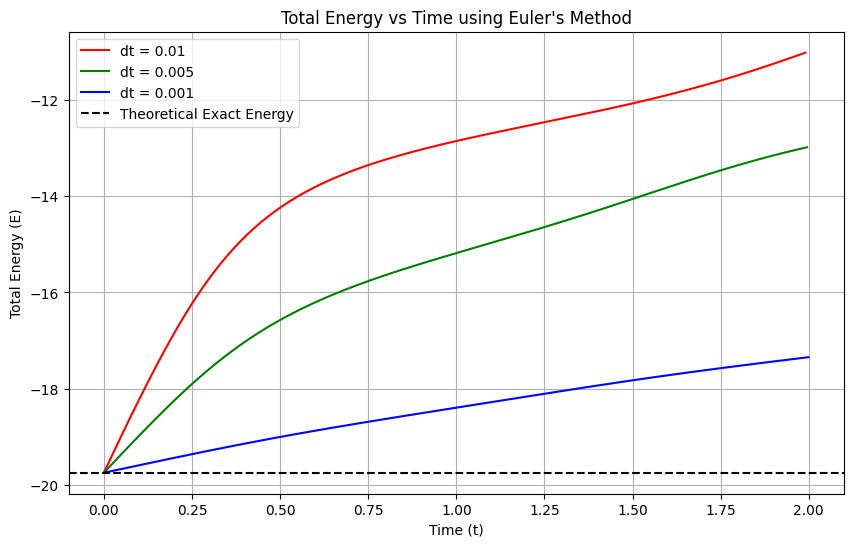

In [5]:
# =====================================================================
# Plotting Energy vs Time for different step-sizes
# =====================================================================

# Create a time array for each simulation based on their dt
time1 = np.arange(0, total_t_dt, dt1)
time2 = np.arange(0, total_t_dt, dt2)
time3 = np.arange(0, total_t_dt, dt3)

plt.figure(figsize=(10, 6))

# Plot energy for each step size
plt.plot(time1, e1, label=f'dt = {dt1}', color='red')
plt.plot(time2, e2, label=f'dt = {dt2}', color='green')
plt.plot(time3, e3, label=f'dt = {dt3}', color='blue')

# The theoretical initial energy for a circular orbit where v = sqrt(k/r), r=1
# E = 0.5 * v^2 - k/r = 0.5 * (4*pi^2) - 4*pi^2 = -2*pi^2
theoretical_energy = -2 * np.pi**2
plt.axhline(theoretical_energy, color='black', linestyle='--', label='Theoretical Exact Energy')

plt.title("Total Energy vs Time using Euler's Method")
plt.xlabel("Time (t)")
plt.ylabel("Total Energy (E)")
plt.legend()
plt.grid(True)
plt.show()

### Comments and Observations on the Results

1. **Orbital Shapes (Part a):**
   * By adjusting the initial velocity ($v_0$), we successfully generated different closed trajectories. Setting $v_0 = \sqrt{k/r} = 2\pi$ yielded a circular orbit, as the initial kinetic energy perfectly balanced the required centripetal force. Setting $v_0$ to a higher value ($4.5$) that is still below the escape velocity yielded an elliptical orbit.

2. **Dependence on Step-Size (Part a):**
   * The graphical output clearly shows that Euler's method is highly sensitive to the step-size ($\Delta t$). For the largest step-size ($\Delta t = 0.01$), the trajectory rapidly spirals outward and fails to close. As $\Delta t$ decreases to $0.001$, the orbit becomes tighter and closer to the true circular path, though it still exhibits slight outward drifting over multiple periods.

3. **Energy Analysis (Part b):**
   * **Energy is NOT conserved.** The energy plot reveals that the total energy of the system increases continuously over time for all step-sizes. 
   * This is a known flaw of the standard forward Euler method. It is a first-order, non-symplectic integrator. The local truncation error at each step pushes the state of the system slightly outward, which systematically adds artificial energy to the system (numerical drift).
   * As $\Delta t$ gets smaller, the rate at which energy increases becomes much slower (the slope of the energy line is flatter for $\Delta t = 0.001$ compared to $\Delta t = 0.01$). However, given enough time, standard Euler will eventually cause any bound orbit to spiral off to infinity. 
   * **Conclusion:** While simple to implement, the standard Euler method is generally inappropriate for long-term simulations of conservative orbital mechanics. A symplectic integrator (like the Euler-Cromer or Verlet method) would be required to maintain stable, bounded energy oscillations.